# 06. Квантильная регрессия

Спецификация **М3** (та же, что в pooled OLS, GARCH и rolling-window): зависимая переменная `r_btc`, регрессоры — `ALL_VARS = CRYPTO_VARS + EXTERNAL_VARS`. Расширенный набор `EXTERNAL_VARS_EXT` (с золотом, Δ10Y и EPU) используется отдельно в модели М4 (notebook 03) и в текст ВКР как квантильная спецификация не выносится.

Оцениваем `statsmodels.regression.quantile_regression.QuantReg` для квантилей $\tau \in \{0.1, 0.25, 0.5, 0.75, 0.9\}$. Интерпретация: как меняется влияние факторов в «хвостах» распределения доходности BTC (обвалы vs рост).

Ниже — сводная таблица коэффициентов по $\tau$ для выбранных переменных и графики $\hat\beta(\tau)$.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/merged_weekly.csv', index_col='date', parse_dates=True)
Y_VAR = 'r_btc'
CRYPTO_VARS = ['r_btc_lag', 'log_volume_btc', 'google_trends']
EXTERNAL_VARS = ['r_sp500', 'vix', 'r_dxy']
ALL_VARS = CRYPTO_VARS + EXTERNAL_VARS

sample = df[[Y_VAR] + ALL_VARS].dropna()
y = sample[Y_VAR].values
X = sm.add_constant(sample[ALL_VARS], has_constant='add')

taus = [0.1, 0.25, 0.5, 0.75, 0.9]
results = {tau: QuantReg(y, X).fit(q=tau) for tau in taus}

cols_order = list(X.columns)
full_tbl = pd.DataFrame({tau: results[tau].params for tau in taus}).T
full_tbl.index.name = 'tau'
print('Коэффициенты по квантилям (все регрессоры):')
display(full_tbl.round(4))


Коэффициенты по квантилям (все регрессоры):


,const,r_btc_lag,log_volume_btc,google_trends,r_sp500,vix,r_dxy,r_gold,d_yield_10y,epu
tau,,,,,,,,,,
0.10,0.1445,-0.0581,-0.0258,-0.0007,1.1046,-0.0009,2.2504,0.5989,0.0381,0.0006
0.25,-0.0004,-0.0220,-0.0017,-0.0002,0.8848,-0.0020,-0.5622,0.2677,0.0434,0.0001
0.50,-0.0161,0.0147,0.0014,0.0002,0.6152,-0.0004,0.0463,0.1543,0.0179,0.0000
0.75,0.0783,0.1568,0.0007,0.0007,0.5329,0.0012,-0.9500,0.1913,-0.0106,-0.0003
0.90,0.0618,0.0912,0.0071,0.0009,0.0187,0.0014,-1.3942,0.2064,-0.1079,-0.0004


In [10]:
key_vars = ['r_sp500', 'vix', 'r_dxy', 'r_btc_lag']
sub_tbl = pd.DataFrame({tau: results[tau].params.loc[key_vars] for tau in taus}).T
sub_tbl.index.name = 'tau'
print('Выбранные регрессоры М3:')
display(sub_tbl.round(4))


Выбранные внешние факторы и Δ10Y:


,r_sp500,vix,r_gold,d_yield_10y
tau,,,,
0.10,1.1046,-0.0009,0.5989,0.0381
0.25,0.8848,-0.0020,0.2677,0.0434
0.50,0.6152,-0.0004,0.1543,0.0179
0.75,0.5329,0.0012,0.1913,-0.0106
0.90,0.0187,0.0014,0.2064,-0.1079


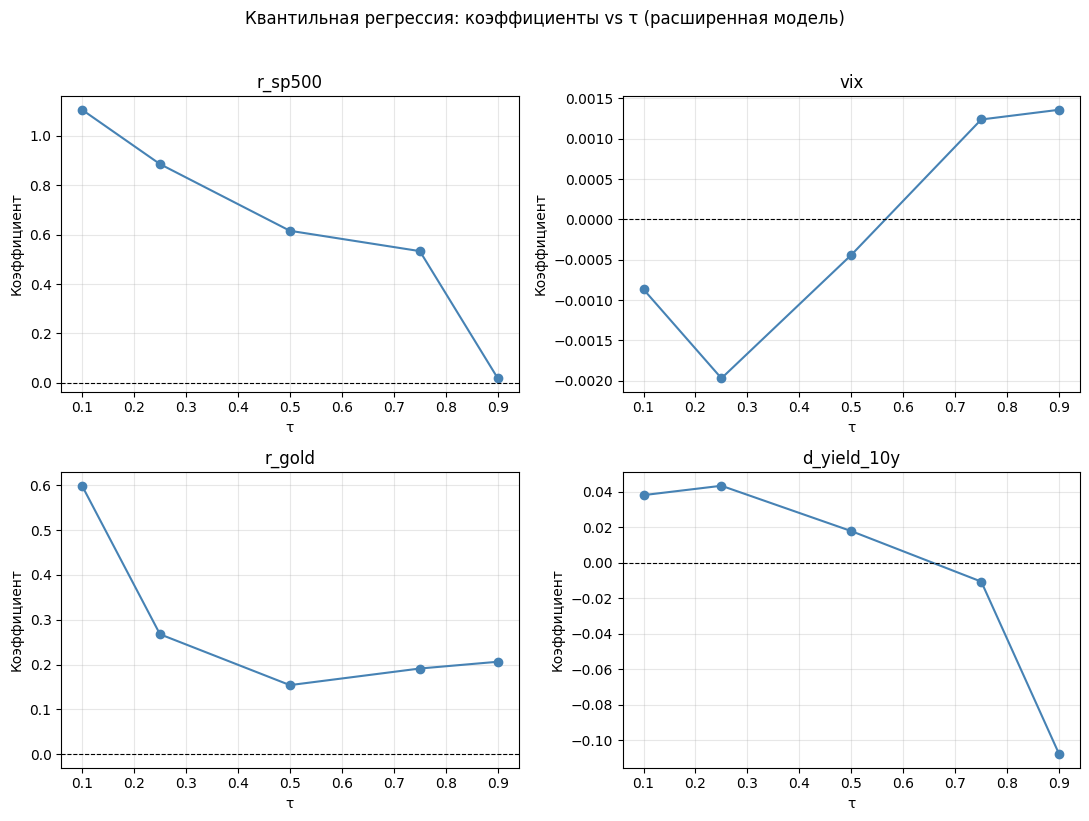

Сохранено: data/processed/quantile_coefs.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes_flat = axes.flatten()
for ax, v in zip(axes_flat, key_vars):
    coefs = [results[t].params[v] for t in taus]
    ax.plot(taus, coefs, 'o-', color='steelblue')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('τ')
    ax.set_ylabel('Коэффициент')
    ax.set_title(v)
    ax.grid(alpha=0.3)
plt.suptitle('Квантильная регрессия: коэффициенты vs τ (модель М3)', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/quantile_coefs.png', dpi=100, bbox_inches='tight')
plt.show()
print('Сохранено: data/processed/quantile_coefs.png')


### Подпериод 2020–2025

In [12]:
# Подпериод 2020–2025 (более зрелый рынок)
p2 = df.loc['2020-01-01':'2025-03-01']
s2 = p2[[Y_VAR] + ALL_VARS].dropna()
y2 = s2[Y_VAR].values
X2 = sm.add_constant(s2[ALL_VARS], has_constant='add')
res_p2 = {tau: QuantReg(y2, X2).fit(q=tau) for tau in taus}
tbl_p2 = pd.DataFrame({tau: res_p2[tau].params.loc[key_vars] for tau in taus}).T
tbl_p2.index.name = 'tau'
print('Подпериод 2020–2025 — коэффициенты при ключевых регрессорах:')
display(tbl_p2.round(4))


Подпериод 2020–2025 — коэффициенты при ключевых регрессорах:


,r_sp500,vix,r_gold,d_yield_10y
tau,,,,
0.10,1.7041,-0.0051,0.2821,0.0431
0.25,0.9572,-0.0023,0.2750,0.0336
0.50,0.7186,-0.0002,0.1986,0.0241
0.75,0.8342,0.0031,0.0942,0.0675
0.90,0.4199,0.0025,0.5443,-0.0151
